In [2]:
# mount your google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
from google.colab import drive
from PIL import Image, UnidentifiedImageError, ExifTags

# Mount Google Drive
drive.mount('/content/drive')

# Define source and target folder mappings
folders = {
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Unripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Unripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Semiripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Semiripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Ripe": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Ripe",
    "/content/drive/MyDrive/TCV BANANA/Real Dataset/train/Overripe-Rotten": "/content/drive/MyDrive/TCV BANANA/Real Dataset/Final/Overripe-Rotten",
}

# Create target folders if they don’t exist
for target_folder in folders.values():
    os.makedirs(target_folder, exist_ok=True)

# Process each category
for source_folder, target_folder in folders.items():
    image_files = sorted(
        [f for f in os.listdir(source_folder) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    )

    if not image_files:
        print(f"No images found in {source_folder}. Skipping...")
        continue

    for image_file in image_files:
        try:
            image_path = os.path.join(source_folder, image_file)

            try:
                image = Image.open(image_path)
            except UnidentifiedImageError:
                print(f"Error: Unable to open '{image_file}'. Skipping...")
                continue

            # Handle EXIF orientation
            try:
                for orientation in ExifTags.TAGS.keys():
                    if ExifTags.TAGS[orientation] == 'Orientation':
                        break
                exif = dict(image._getexif().items())
                if exif.get(orientation) == 3:
                    image = image.rotate(180, expand=True)
                elif exif.get(orientation) == 6:
                    image = image.rotate(270, expand=True)
                elif exif.get(orientation) == 8:
                    image = image.rotate(90, expand=True)
            except (AttributeError, KeyError, IndexError):
                pass

            # Resize image while maintaining aspect ratio
            image.thumbnail((224, 224), Image.Resampling.LANCZOS)

            # Create a white background canvas
            new_image = Image.new("RGB", (224, 224), (255, 255, 255))

            # Paste centered image
            paste_x = (224 - image.size[0]) // 2
            paste_y = (224 - image.size[1]) // 2
            new_image.paste(image, (paste_x, paste_y))

            # Define output filename (same as source image name)
            output_path = os.path.join(target_folder, image_file)
            new_image.save(output_path)

            print(f"Saved: {image_file}")
        except Exception as e:
            print(f"Error processing '{image_file}': {e}")

print("Resizing and padding completed!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: Unripe_001.jpg
Saved: Unripe_002.jpg
Saved: Unripe_003.jpg
Saved: Unripe_004.jpg
Saved: Unripe_005.jpg
Saved: Unripe_006.jpg
Saved: Unripe_007.jpg
Saved: Unripe_008.jpg
Saved: Unripe_009.jpg
Saved: Unripe_010.jpg
Saved: Unripe_011.jpg
Saved: Unripe_012.jpg
Saved: Unripe_013.jpg
Saved: Unripe_014.jpg
Saved: Unripe_015.jpg
Saved: Unripe_016.jpg
Saved: Unripe_017.jpg
Saved: Unripe_018.jpg
Saved: Unripe_019.jpg
Saved: Unripe_020.jpg
Saved: Unripe_021.jpg
Saved: Unripe_022.jpg
Saved: Unripe_023.jpg
Saved: Unripe_024.jpg
Saved: Unripe_025.jpg
Saved: Unripe_026.jpg
Saved: Unripe_027.jpg
Saved: Unripe_028.jpg
Saved: Unripe_029.jpg
Saved: Unripe_030.jpg
Saved: Unripe_031.jpg
Saved: Unripe_032.jpg
Saved: Unripe_033.jpg
Saved: Unripe_034.jpg
Saved: Unripe_035.jpg
Saved: Unripe_036.jpg
Saved: Unripe_037.jpg
Saved: Unripe_038.jpg
Saved: Unripe_039.jpg
Saved: Unripe

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from typing import List, Tuple


In [4]:
# Directory paths for banana ripeness stages
ripeness_dirs = {
    'Unripe': '/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Testing/LQ/Unripe',
    'Semiripe': '/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Testing/LQ/Semiripe',
    'Ripe': '/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Testing/LQ/Ripe',
    'Overripe-Rotten': '/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Testing/LQ/Overripe-Rotten'
}

In [5]:
# Mapping of ripeness stages to numerical labels
ripeness_labels = {
    'Unripe': 0,
    'Semiripe': 1,
    'Ripe': 2,
    'Overripe-Rotten': 3
}

In [6]:
# Function to display banana ripeness images in a grid
def display_ripeness_stages_grid(sample_images, class_titles, plot_title):
    total_samples = len(sample_images)
    columns = 10
    rows = (total_samples // columns) + 1 if total_samples % columns != 0 else total_samples // columns

    figure, axis_array = plt.subplots(rows, columns, figsize=(20, rows * 2))
    axis_array = axis_array.flatten()

    for axis, sample_img, class_title in zip(axis_array, sample_images, class_titles):
        axis.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
        axis.set_title(class_title, fontsize=8)
        axis.axis('off')

    # Hide empty subplots
    for axis in axis_array[len(sample_images):]:
        axis.axis('off')

    figure.suptitle(plot_title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Load and display all the images from each folder
def load_and_display_random_images(ripeness_dirs, num_samples=50):
    """Load and display random images from each ripeness class folder."""

    for ripeness_class, class_dir in ripeness_dirs.items():
        print(f"\nProcessing: {ripeness_class}")

        # Get all files and randomly sample
        class_files = os.listdir(class_dir)
        sample_size = min(num_samples, len(class_files))
        sampled_files = random.sample(class_files, sample_size) if class_files else []

        # Load images
        images, titles = [], []
        for filename in sampled_files:
            img = cv2.imread(os.path.join(class_dir, filename))
            if img is not None:
                images.append(img)
                titles.append(f"{ripeness_class}\n{filename}")
            else:
                print(f"Could not load: {filename}")

        # Display results
        if images:
            print(f"Showing {len(images)}/{len(class_files)} available images")
            display_ripeness_stages_grid(
                sample_images=images,
                class_titles=titles,
                plot_title=f"Random Sample from {ripeness_class}"
            )

# To use:
load_and_display_random_images(ripeness_dirs)

## **IMAGE PREPROCESSING TECHNIQUES**

In [10]:
def apply_gamma_correction(image: np.ndarray, gamma: float = 1.2) -> np.ndarray:
    """Applies gamma correction to enhance image contrast."""
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

def apply_clahe_lab(image: np.ndarray, clip_limit: float = 2.5, grid_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """Applies CLAHE in LAB color space."""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    return cv2.cvtColor(cv2.merge((clahe.apply(l), clahe.apply(a), clahe.apply(b))), cv2.COLOR_LAB2BGR)

def apply_median_filter(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """Applies median filtering for noise reduction."""
    return cv2.medianBlur(image, kernel_size)

def full_preprocessing_pipeline(image: np.ndarray) -> np.ndarray:
    """Combines all preprocessing steps."""
    image = apply_gamma_correction(image)
    image = apply_clahe_lab(image)
    return apply_median_filter(image)

## **SEGMENTATION TECHNIQUES**

In [17]:
def create_hsv_mask(image: np.ndarray) -> np.ndarray:
    """Creates combined HSV mask for banana detection."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Define color ranges
    lower = [
        np.array([25, 30, 30]),  # Green
        np.array([10, 50, 50]),  # Yellow
        np.array([0, 5, 5])      # Brown
    ]
    upper = [
        np.array([95, 255, 255]),
        np.array([45, 255, 255]),
        np.array([50, 180, 180])
    ]
    masks = [cv2.inRange(hsv, l, u) for l, u in zip(lower, upper)]
    return cv2.bitwise_or(masks[0], cv2.bitwise_or(masks[1], masks[2]))

def improved_grabcut(image: np.ndarray, mask: np.ndarray, iterations: int = 4) -> np.ndarray:
    """Applies improved GrabCut algorithm with error handling."""
    # Validate input mask
    if np.all(mask == 0):
        raise ValueError("Empty HSV mask - cannot initialize GrabCut")

    # Find bounding box with safety checks
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(main_contour)
        # Ensure valid bounding box coordinates
        x = max(x-10, 0)
        y = max(y-10, 0)
        w = min(w+20, image.shape[1]-x)
        h = min(h+20, image.shape[0]-y)
        rect = (x, y, w, h)
    else:
        # Use central region as fallback
        h, w = image.shape[:2]
        rect = (w//4, h//4, w//2, h//2)

    # Initialize GrabCut mask with safety margin
    grabcut_mask = np.zeros(image.shape[:2], np.uint8)

    # Set probable foreground with buffer zone
    grabcut_mask[mask > 0] = cv2.GC_PR_FGD
    grabcut_mask[mask == 0] = cv2.GC_BGD

    # Add guaranteed foreground/background regions
    cv2.rectangle(grabcut_mask, (rect[0], rect[1]),
                 (rect[0]+rect[2], rect[1]+rect[3]),
                 cv2.GC_FGD, thickness=2)
    cv2.rectangle(grabcut_mask, (0, 0), (image.shape[1]-1, image.shape[0]-1),
                 cv2.GC_BGD, thickness=10)

    # Initialize models
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        # Run GrabCut with error handling
        cv2.grabCut(image, grabcut_mask, rect, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_RECT)
        for _ in range(iterations-1):
            cv2.grabCut(image, grabcut_mask, None, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_MASK)
    except cv2.error as e:
        print(f"GrabCut warning: {str(e)} - using fallback mask")
        return mask  # Return original HSV mask as fallback

    return np.where((grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD), 255, 0).astype('uint8')

def postprocess_mask(mask: np.ndarray, kernel_size: int = 7) -> np.ndarray:
    """Applies morphological operations to refine mask."""
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

## **VISUALIZATION TECHNIQUES**

In [18]:
def display_results(images: List[np.ndarray], titles: List[str],
                    figsize: Tuple[int, int] = (20, 4), cols: int = 10) -> None:
    """Displays images in a grid layout with titles."""
    rows = 1
    figure, axes = plt.subplots(rows, cols, figsize=figsize)
    for ax, img, title in zip(axes.flatten(), images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## **MAIN PROCESSING PIPELINE**

In [19]:
def process_single_image(image_path: str) -> np.ndarray:
    """Full processing pipeline for a single image."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Preprocessing
    preprocessed = full_preprocessing_pipeline(img)

    # Segmentation
    hsv_mask = create_hsv_mask(preprocessed)
    grabcut_mask = improved_grabcut(preprocessed, hsv_mask)
    final_mask = postprocess_mask(grabcut_mask)

    # Apply mask
    result = preprocessed.copy()
    result[final_mask == 0] = 0
    return result

## **Save The Data into Folder**

In [41]:
def process_and_save_images(input_dir: str, output_dir: str):
    """Applies preprocessing and saves images."""
    categories = ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]

    for category in categories:
        folder_path = os.path.join(input_dir, category)
        save_path = os.path.join(output_dir, category)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)

            # Read the image
            image = cv2.imread(file_path)
            if image is None:
                print(f"Could not load image: {file_path}")
                continue

            # Apply preprocessing steps
            preprocessed_image = full_preprocessing_pipeline(image)

            # Save the processed image
            save_file_path = os.path.join(save_path, filename)
            cv2.imwrite(save_file_path, preprocessed_image)
            print(f"Processed and saved: {save_file_path}")

# Define paths
data_dir = "/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Final"
save_dir = "/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3"

# Run processing
process_and_save_images(data_dir, save_dir)


Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_001.png
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_002.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_003.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_004.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_005.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_006.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_007.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/Ripe/Ripe_008.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/R

## **VISUALIZATION OF SAMPLES**

In [ ]:
def visualize_processing_steps(image_path: str) -> Tuple[List[np.ndarray], List[str]]:
    """Returns all processing stages for an image."""
    original = cv2.imread(image_path)
    if original is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Preprocessing steps
    gamma = apply_gamma_correction(original)
    clahe = apply_clahe_lab(gamma)
    median = apply_median_filter(clahe)

    # Segmentation steps
    hsv_mask = create_hsv_mask(median)
    grabcut_mask = improved_grabcut(median, hsv_mask)
    final_mask = postprocess_mask(grabcut_mask)

    # Final result
    result = median.copy()
    result[final_mask == 0] = 0

    # Convert all to RGB for display
    stages = [original, gamma, clahe, median,
              cv2.cvtColor(hsv_mask, cv2.COLOR_GRAY2RGB),
              cv2.cvtColor(grabcut_mask, cv2.COLOR_GRAY2RGB),
              cv2.cvtColor(final_mask, cv2.COLOR_GRAY2RGB),
              result]

    titles = [
        "Original", "Gamma Corrected", "CLAHE Applied",
        "Median Filtered", "HSV Mask", "GrabCut Mask",
        "Postprocessed Mask", "Final Result"
    ]

    return stages, titles

def display_processing_pipeline(ripeness_dirs, samples_per_class=20):
    """Displays full processing pipeline for random samples."""
    plt.figure(figsize=(20, 10))

    for class_idx, (class_name, class_dir) in enumerate(ripeness_dirs.items()):
        try:
            # Get random samples
            all_files = os.listdir(class_dir)
            if not all_files:
                print(f"Skipping empty class: {class_name}")
                continue

            sampled_files = random.sample(all_files, min(samples_per_class, len(all_files)))

            # Process and display images
            for img_idx, fname in enumerate(sampled_files):
                try:
                    stages, titles = visualize_processing_steps(os.path.join(class_dir, fname))

                    # Create grid for one sample
                    cols = len(stages)
                    rows = samples_per_class

                    # Create new figure every 5 samples
                    if img_idx % 5 == 0:
                        plt.close()
                        fig, axs = plt.subplots(5, cols, figsize=(24, 20))
                        fig.suptitle(f"Processing Steps - {class_name} (Samples {img_idx+1}-{min(img_idx+5, samples_per_class)})",
                                   fontsize=16, y=1.02)

                    # Plot all steps for current image
                    for col_idx, (stage, title) in enumerate(zip(stages, titles)):
                        current_ax = axs[img_idx%5, col_idx]
                        current_ax.imshow(cv2.cvtColor(stage, cv2.COLOR_BGR2RGB)
                                         if len(stage.shape) == 3 else stage,
                                         cmap='gray' if len(stage.shape) == 2 else None)
                        current_ax.set_title(title, fontsize=10)
                        current_ax.axis('off')

                    # Show every 5 samples
                    if (img_idx+1) % 5 == 0 or img_idx == len(sampled_files)-1:
                        plt.tight_layout()
                        plt.show()

                except Exception as e:
                    print(f"Error processing {fname}: {str(e)}")
                    continue

        except Exception as e:
            print(f"Error processing class {class_name}: {str(e)}")
            continue

# Usage
random.seed(42)  # For reproducible sampling
display_processing_pipeline(ripeness_dirs, samples_per_class=20)

## **VISUALIZATION OF PREPROCESSED DATASET**

In [ ]:
if __name__ == "__main__":
    for class_name, class_dir in ripeness_dirs.items():
        print(f"\nProcessing: {class_name}")

        images = []
        titles = []
        processed_count = 0
        error_count = 0

        try:
            # Get all files and process up to 50 valid ones
            all_files = os.listdir(class_dir)
            total_files = len(all_files)

            if total_files == 0:
                print(f"No images found in {class_dir}")
                continue

            # Try processing files until we get 50 successful or exhaust all files
            for fname in all_files:
                if processed_count >= 50:
                    break

                try:
                    result_img = process_single_image(os.path.join(class_dir, fname))
                    images.append(result_img)
                    titles.append(f"{class_name}\n{fname}")
                    processed_count += 1

                except Exception as e:
                    error_count += 1
                    # Stop if we've tried 3x the desired sample size without success
                    if error_count > 150:
                        print(f"Too many errors, stopping processing for {class_name}")
                        break
                    continue

            # Dynamic grid calculation
            if images:
                cols = 10
                rows = (processed_count + cols - 1) // cols
                print(f"Displaying {processed_count} images ({error_count} errors)")

                figure, axis_array = plt.subplots(rows, cols, figsize=(20, 2 * rows))
                axis_array = axis_array.flatten()

                for ax, img, title in zip(axis_array, images, titles):
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    ax.set_title(title, fontsize=8)
                    ax.axis('off')

                # Hide empty subplots
                for ax in axis_array[len(images):]:
                    ax.axis('off')

                plt.tight_layout()
                plt.show()
            else:
                print(f"No valid images processed for {class_name}")

        except Exception as e:
            print(f"Fatal error processing {class_name}: {str(e)}")

## **PROCESSING OWN DATASET**

In [36]:
# Define preprocessing functions (same as before)
def resize_image(image: np.ndarray, size: Tuple[int, int] = (224, 224)) -> np.ndarray:
    """Resizes the image to the specified size."""
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)

def process_and_save_images(input_dir: str, output_dir: str):
    """Resizes images to 224x224, applies preprocessing, and saves them."""
    categories = ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]

    for category in categories:
        folder_path = os.path.join(input_dir, category)
        save_path = os.path.join(output_dir, category)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)

            # Read the image
            image = cv2.imread(file_path)
            if image is None:
                print(f"Could not load image: {file_path}")
                continue

            # Resize the image
            resized_image = resize_image(image)

            # Apply preprocessing steps
            preprocessed_image = full_preprocessing_pipeline(resized_image)

            # Save the processed image
            save_file_path = os.path.join(save_path, filename)
            cv2.imwrite(save_file_path, preprocessed_image)
            print(f"Processed and saved: {save_file_path}")

# Define paths
new_data_dir = "/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Own"
new_save_dir = "/content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset"

# Run processing
process_and_save_images(new_data_dir, new_save_dir)


Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_533.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_530.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_585.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_441.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_439.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_551.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA/Real Dataset/Preprocessed/Experiment_3/OwnDataset/Ripe/Crop_1211103510_525.jpg
Processed and saved: /content/gdrive/MyDrive/TCV BANANA

## **LOAD & VISUALIZE 10 RANDOM PROCESSED IMAGES PER CLASS**

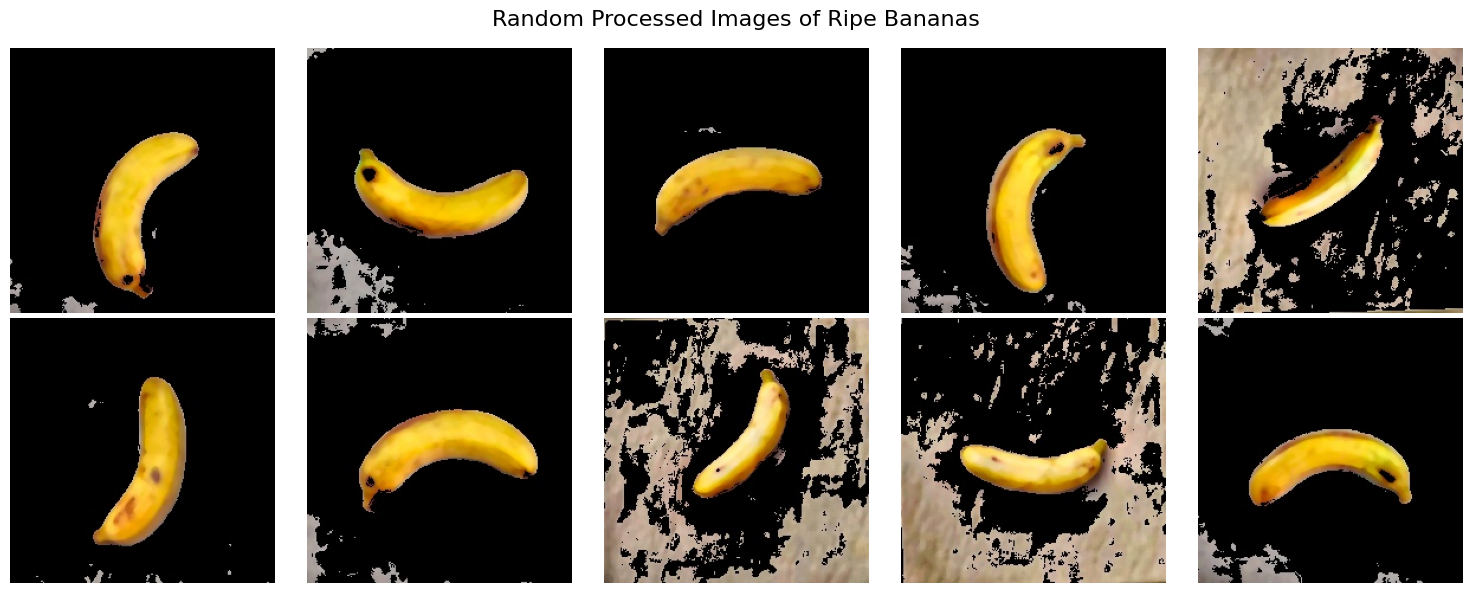

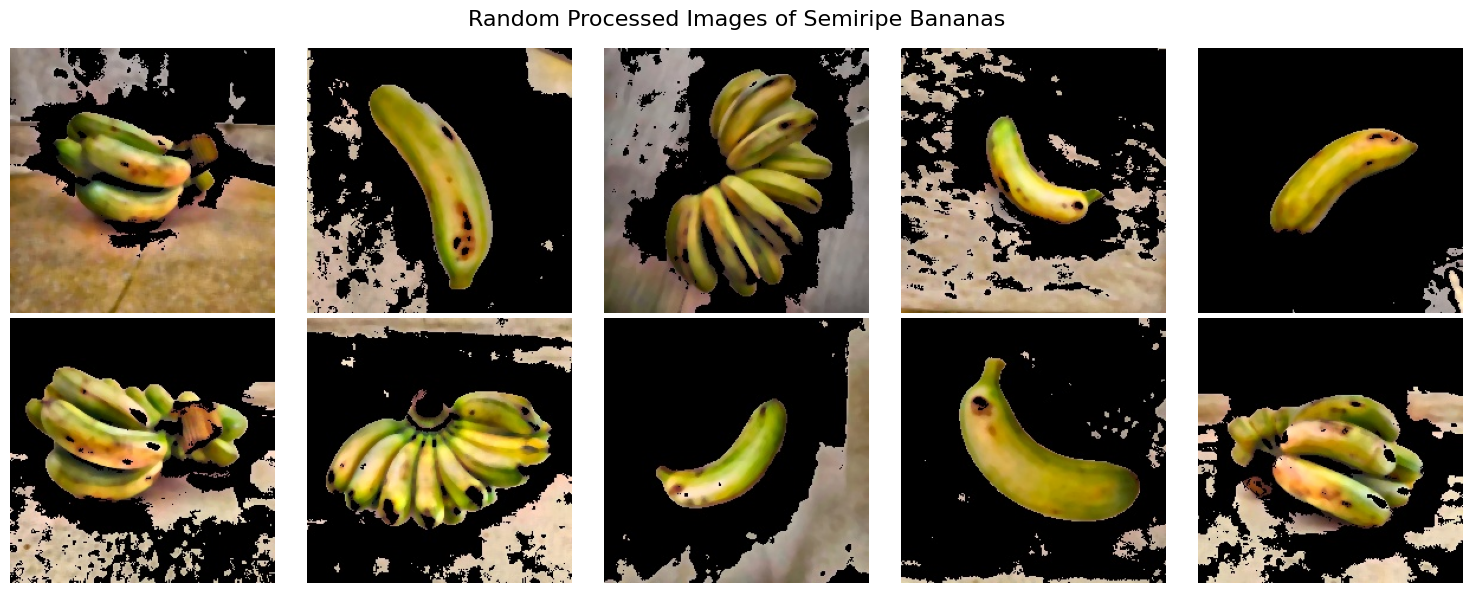

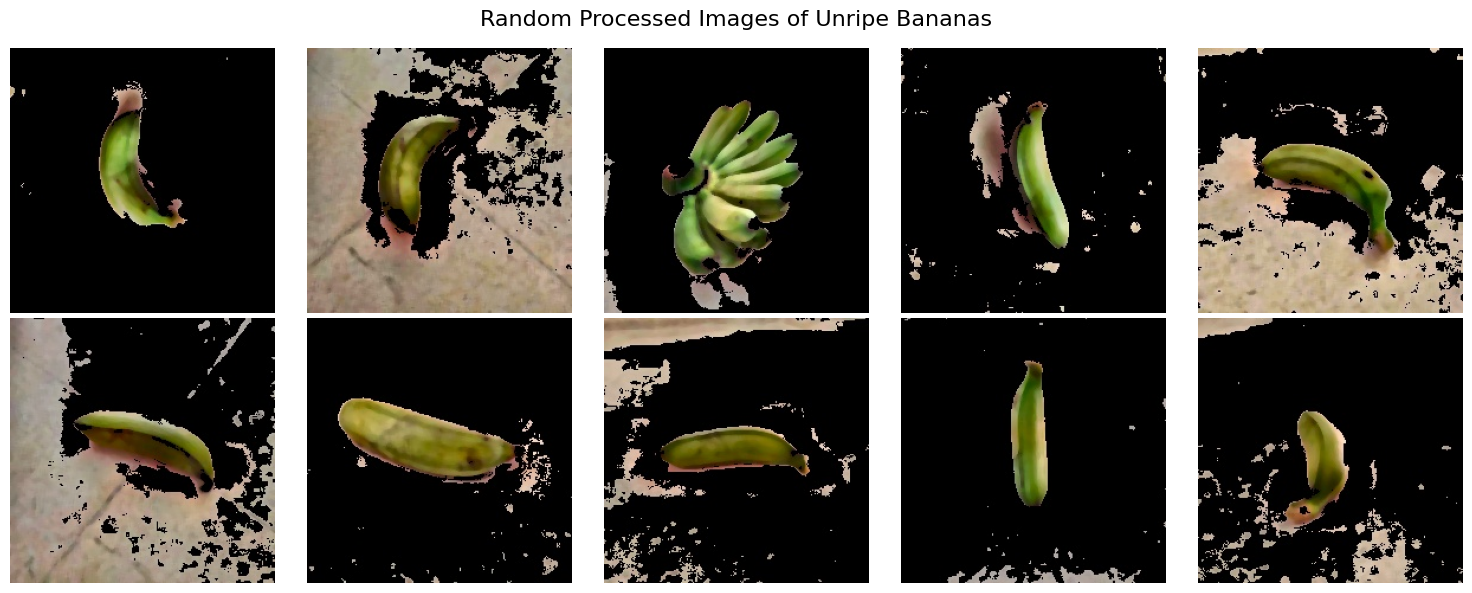

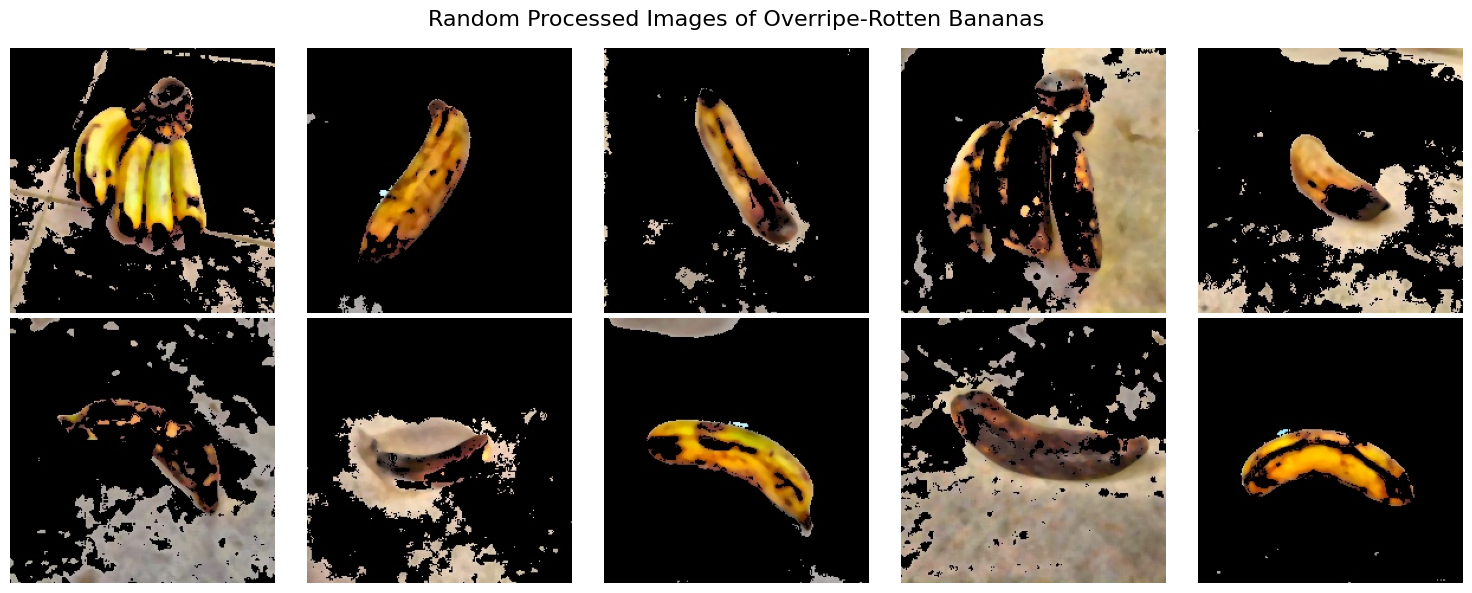

In [39]:
# Set a fixed seed for reproducibility
random.seed(42)

# Load & visualize 10 random processed images per class
for category in ["Ripe", "Semiripe", "Unripe", "Overripe-Rotten"]:
    category_save_dir = os.path.join(new_save_dir, category)

    if not os.path.exists(category_save_dir):
        print(f"Skipping visualization: {category} folder not found in Experiment_3 > Own")
        continue

    saved_images = os.listdir(category_save_dir)
    if not saved_images:
        print(f"No saved images found for {category}")
        continue

    sample_images = random.sample(saved_images, min(10, len(saved_images)))

    # Define subplot grid
    num_images = len(sample_images)
    cols = min(5, num_images)  # Maximum 5 columns
    rows = (num_images + cols - 1) // cols  # Calculate necessary rows

    plt.figure(figsize=(15, 3 * rows))
    plt.suptitle(f"Random Processed Images of {category} Bananas", fontsize=16)

    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(category_save_dir, image_name)
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)  # Read with unchanged channels

        if img is None:
            print(f"Skipping corrupted/missing file: {image_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for proper display

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()